<h1><b>Configuración y librerías

In [1]:
# Librerías
# Librerías
import torch
import numpy as np
import random
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.functional as TF

from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet18
from copy import deepcopy
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             f1_score, recall_score, precision_score)
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [2]:
# Rutas
DATOS_DIR = Path("../preprocesamiento/output/center_4/preprocesamiento_train")
TEST_DIR = Path("../preprocesamiento/output/center_4/preprocesamiento_test")

# Uso GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# HIPERPARÁMETROS
BATCH_SIZE = 16      # imágenes por batch
EPOCHS     = 30      # número de épocas
LR         = 0.0004    # learning rate
VAL_SPLIT  = 0.2     # 20% para validación



Dispositivo: cuda


In [3]:
# Semilla para reproducibilidad
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)          # ← cubre todas las GPUs, no solo 1
    torch.backends.cudnn.deterministic = True  # ← operaciones CUDA deterministas
    torch.backends.cudnn.benchmark = False     # ← desactiva autotuner no determinista

set_seed(SEED)

<h1><b>Dataset

In [4]:
# P0003_S0033_STROKE.npy label = 1
# P0002_S0027_CONTROL.npy label = 0

class StrokeDataset(Dataset):

    def __init__(self, archivos, augment=False):
        self.archivos = archivos
        self.augment  = augment

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)

        if self.augment:
            if random.random() > 0.5:
                imagen = TF.hflip(imagen)
            if random.random() > 0.5:
                imagen = TF.vflip(imagen)
            if random.random() > 0.5:
                angle  = random.uniform(-15, 15)
                imagen = TF.rotate(imagen, angle)

        nombre = ruta.stem
        label  = 1 if "STROKE" in nombre else 0
        return imagen, torch.tensor(label, dtype=torch.float32)


# Verificación
todos_los_archivos = sorted(DATOS_DIR.glob("*.npy"))

print(f"Total archivos : {len(todos_los_archivos)}")

strokes   = sum(1 for f in todos_los_archivos if "STROKE"  in f.stem)
controles = sum(1 for f in todos_los_archivos if "CONTROL" in f.stem)
print(f"STROKE         : {strokes}")
print(f"CONTROL        : {controles}")

dataset_prueba = StrokeDataset(todos_los_archivos)
imagen, label  = dataset_prueba[0]
print(f"\nEjemplo cargado:")
print(f"  Shape  : {imagen.shape}")
print(f"  Label  : {label.item()} ({'STROKE' if label.item()==1 else 'CONTROL'})")

Total archivos : 1280
STROKE         : 692
CONTROL        : 588

Ejemplo cargado:
  Shape  : torch.Size([2, 112, 112])
  Label  : 0.0 (CONTROL)


<h1><b>Split y DataLoader

In [5]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    
g = torch.Generator()
g.manual_seed(SEED)

In [6]:
total    = len(todos_los_archivos)
val_size = int(total * VAL_SPLIT)
train_size = total - val_size

archivos_train, archivos_val = random_split(
    todos_los_archivos,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Convertir a lista para pasarlos al Dataset
archivos_train = [todos_los_archivos[i] for i in archivos_train.indices]
archivos_val   = [todos_los_archivos[i] for i in archivos_val.indices]

# Dataset
dataset_train = StrokeDataset(archivos_train, augment=True)
dataset_val   = StrokeDataset(archivos_val,   augment=False)

# DataLoader
loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    worker_init_fn=seed_worker,   # cada worker arranca con seed fija
    generator=g                   # controla el shuffle
)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False)

# Verificación
print(f"Train : {len(dataset_train)} muestras | {len(loader_train)} batches")
print(f"Val   : {len(dataset_val)}  muestras | {len(loader_val)} batches")

imagenes, labels = next(iter(loader_train))
print(f"\nBatch de prueba:")
print(f"  Imágenes : {imagenes.shape}")
print(f"  Labels   : {labels.shape} | {labels}")

Train : 1024 muestras | 64 batches
Val   : 256  muestras | 16 batches

Batch de prueba:
  Imágenes : torch.Size([16, 2, 112, 112])
  Labels   : torch.Size([16]) | tensor([0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0.])


<h1> <b> Modelo de entrenamiento

In [222]:
# Qué canales importan más
class ChannelAttention(nn.Module):
    def __init__(self, canales, reduccion=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(canales, canales // reduccion),
            nn.ReLU(),
            nn.Linear(canales // reduccion, canales)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.mlp(self.max_pool(x).squeeze(-1).squeeze(-1))
        return self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1) * x

# Qué zonas de la imagen importan más
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_ = x.max(dim=1, keepdim=True).values
        mapa = torch.cat([avg, max_], dim=1)
        return self.sigmoid(self.conv(mapa)) * x


class CBAM(nn.Module):
    def __init__(self, canales):
        super().__init__()
        self.channel = ChannelAttention(canales)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

In [223]:
# Arquitectura ResNet-18 con CBAM
class ResNet18CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet-18 base
        base = resnet18(weights=None)

        # Primera capa: 3 canales a 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Guardamos las capas de ResNet
        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        # CBAM después de cada capa residual
        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)

        # Clasificador final: 1 neurona para STROKE/CONTROL
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))

        x = self.cbam1(self.layer1(x))
        x = self.cbam2(self.layer2(x))
        x = self.cbam3(self.layer3(x))
        x = self.cbam4(self.layer4(x))

        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x

In [224]:
set_seed(SEED)
modelo = ResNet18CBAM().to(DEVICE)

# Pasar un batch de prueba
with torch.no_grad():
    salida = modelo(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo.parameters())

print(f"Entrada : {imagenes.shape}")
print(f"Salida  : {salida.shape}")
print(f"Parámetros totales: {total_params:,}")

Entrada : torch.Size([16, 2, 112, 112])
Salida  : torch.Size([16, 1])
Parámetros totales: 11,218,825


<h1><b> Entrenamiento

In [225]:
# Weighted BCE para center_4
# n_control / n_stroke = 588 / 692
n_stroke_c4   = 692
n_control_c4  = 588
pos_weight_c4 = torch.tensor([n_control_c4 / n_stroke_c4]).to(DEVICE)

In [226]:
#criterio  = nn.BCEWithLogitsLoss()           # Loss para clasificación binaria
criterio  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_c4)
optimizer = torch.optim.AdamW(modelo.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Early stopping
PACIENCIA        = 7      # épocas sin mejora antes de parar
mejor_val_loss   = float("inf")
epocas_sin_mejora = 0
mejor_modelo     = None

# Ruta donde guardar el mejor modelo
MODELO_DIR  = Path("modelos")
MODELO_DIR.mkdir(exist_ok=True)
MODELO_PATH = MODELO_DIR / "resnet18_cbam_mejor.pth"

# Loop de entrenamiento
historial = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    # TRAIN
    modelo.train()
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()

        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    # VALIDACIÓN
    modelo.eval()
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)

            salida  = modelo(imagenes)
            loss    = criterio(salida, labels)

            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    # METRICAS
    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)

    scheduler.step()

    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    # GUARDAR MEJOR MODELO
    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo.state_dict())
        torch.save(mejor_modelo, MODELO_PATH)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")

    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    # EARLY STOPPING
    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH}")

Época 01/30 | Train loss: 0.3870 acc: 0.7988 | Val loss: 0.3585 acc: 0.8047 | 3.3s
  ✔ Mejor modelo guardado (val_loss: 0.3585)
Época 02/30 | Train loss: 0.2086 acc: 0.9043 | Val loss: 0.2684 acc: 0.8750 | 3.1s
  ✔ Mejor modelo guardado (val_loss: 0.2684)
Época 03/30 | Train loss: 0.1455 acc: 0.9404 | Val loss: 0.2053 acc: 0.8828 | 3.1s
  ✔ Mejor modelo guardado (val_loss: 0.2053)
Época 04/30 | Train loss: 0.1224 acc: 0.9521 | Val loss: 0.2870 acc: 0.9023 | 3.1s
  Sin mejora 1/7
Época 05/30 | Train loss: 0.0523 acc: 0.9805 | Val loss: 0.2040 acc: 0.9375 | 3.1s
  ✔ Mejor modelo guardado (val_loss: 0.2040)
Época 06/30 | Train loss: 0.0667 acc: 0.9727 | Val loss: 0.2251 acc: 0.9102 | 3.1s
  Sin mejora 1/7
Época 07/30 | Train loss: 0.0452 acc: 0.9795 | Val loss: 0.2938 acc: 0.9141 | 3.1s
  Sin mejora 2/7
Época 08/30 | Train loss: 0.0178 acc: 0.9941 | Val loss: 0.3366 acc: 0.9062 | 3.1s
  Sin mejora 3/7
Época 09/30 | Train loss: 0.0437 acc: 0.9795 | Val loss: 0.2137 acc: 0.9297 | 3.1s
  Sin

<h1> <b> Evaluación

In [227]:
archivos_test = sorted(TEST_DIR.glob("*.npy"))

print(f"Total test : {len(archivos_test)}")
print(f"STROKE     : {sum(1 for f in archivos_test if 'STROKE'  in f.stem)}")
print(f"CONTROL    : {sum(1 for f in archivos_test if 'CONTROL' in f.stem)}")

# Dataset y loader
dataset_test = StrokeDataset(archivos_test)
loader_test  = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

# Cargar el mejor modelo
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo(imagenes)
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)

print("RESULTADOS — VALIDACIÓN")

print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")

Total test : 320
STROKE     : 173
CONTROL    : 147
RESULTADOS — VALIDACIÓN
  AUC-ROC       : 0.8146
  Accuracy      : 0.5719
  F1-Score      : 0.3445
  Sensibilidad  : 0.2081  (detecta STROKE)
  Especificidad : 1.0000  (detecta CONTROL)
  Precisión     : 1.0000


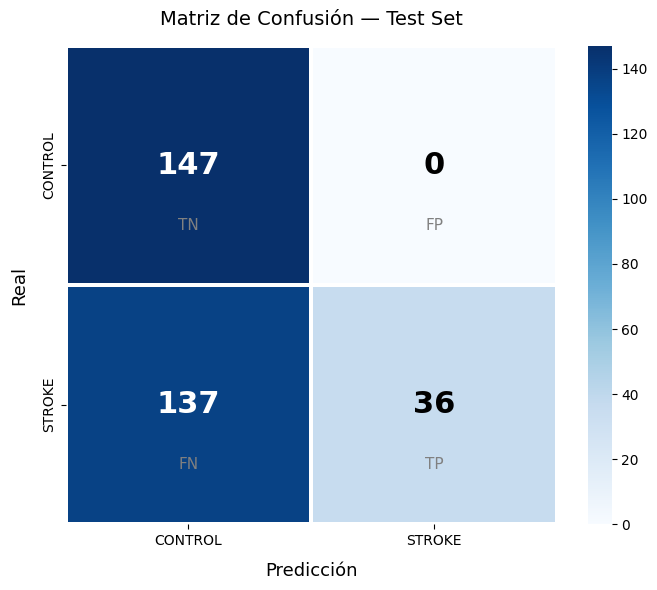

In [228]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h1><b> Entrenamiento sin CBAM

In [230]:
class ResNet18Base(nn.Module):
    def __init__(self):
        super().__init__()

        base = resnet18(weights=None)

        # Modificamos la primera capa: 3 canales - 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x


# Verificación
set_seed(SEED)
modelo_base = ResNet18Base().to(DEVICE)

with torch.no_grad():
    salida = modelo_base(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo_base.parameters())
print(f"Entrada    : {imagenes.shape}")
print(f"Salida     : {salida.shape}")
print(f"Parámetros : {total_params:,}")

Entrada    : torch.Size([16, 2, 112, 112])
Salida     : torch.Size([16, 1])
Parámetros : 11,173,889


In [231]:
set_seed(SEED)
# Recrear el generator para que el shuffle empiece igual
g = torch.Generator()
g.manual_seed(SEED)
loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g
)

In [232]:
# ENTRENAMIENTO — ResNet18 SIN CBAM
#criterio  = nn.BCEWithLogitsLoss()
criterio  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_c4)
optimizer = torch.optim.AdamW(modelo_base.parameters(), lr=LR)  # modelo_base
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

PACIENCIA         = 7
mejor_val_loss    = float("inf")
epocas_sin_mejora = 0
mejor_modelo      = None

MODELO_PATH_BASE = MODELO_DIR / "resnet18_base_mejor.pth"  # nombre distinto

historial_base = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    modelo_base.train()  # ← modelo_base
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        salida = modelo_base(imagenes)  # ← modelo_base
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()
        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    modelo_base.eval()  # ← modelo_base
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            salida   = modelo_base(imagenes)  # modelo_base
            loss     = criterio(salida, labels)
            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial_base["train_loss"].append(train_loss)
    historial_base["val_loss"].append(val_loss)
    historial_base["train_acc"].append(train_acc)
    historial_base["val_acc"].append(val_acc)

    scheduler.step()
    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo_base.state_dict())
        torch.save(mejor_modelo, MODELO_PATH_BASE)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH_BASE}")

Época 01/30 | Train loss: 0.3718 acc: 0.8193 | Val loss: 0.2501 acc: 0.8867 | 3.0s
  ✔ Mejor modelo guardado (val_loss: 0.2501)
Época 02/30 | Train loss: 0.1615 acc: 0.9355 | Val loss: 0.4015 acc: 0.8008 | 2.9s
  Sin mejora 1/7
Época 03/30 | Train loss: 0.1244 acc: 0.9570 | Val loss: 0.2610 acc: 0.8984 | 2.9s
  Sin mejora 2/7
Época 04/30 | Train loss: 0.0862 acc: 0.9668 | Val loss: 0.2091 acc: 0.9141 | 2.9s
  ✔ Mejor modelo guardado (val_loss: 0.2091)
Época 05/30 | Train loss: 0.0999 acc: 0.9570 | Val loss: 0.4539 acc: 0.8281 | 2.9s
  Sin mejora 1/7
Época 06/30 | Train loss: 0.0332 acc: 0.9912 | Val loss: 0.2503 acc: 0.9180 | 2.9s
  Sin mejora 2/7
Época 07/30 | Train loss: 0.0300 acc: 0.9893 | Val loss: 0.2475 acc: 0.9258 | 2.8s
  Sin mejora 3/7
Época 08/30 | Train loss: 0.0320 acc: 0.9902 | Val loss: 0.3137 acc: 0.9219 | 2.9s
  Sin mejora 4/7
Época 09/30 | Train loss: 0.0355 acc: 0.9844 | Val loss: 0.2748 acc: 0.9141 | 2.9s
  Sin mejora 5/7
Época 10/30 | Train loss: 0.0251 acc: 0.9902

In [233]:
# Cargar el mejor modelo base
modelo_base.load_state_dict(torch.load(MODELO_PATH_BASE, map_location=DEVICE))  # ← base
modelo_base.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo_base(imagenes)  # ← base
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)


print(" RESULTADOS — TEST SET (Sin CBAM)")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")


 RESULTADOS — TEST SET (Sin CBAM)
  AUC-ROC       : 0.6185
  Accuracy      : 0.5875
  F1-Score      : 0.4677
  Sensibilidad  : 0.3353  (detecta STROKE)
  Especificidad : 0.8844  (detecta CONTROL)
  Precisión     : 0.7733


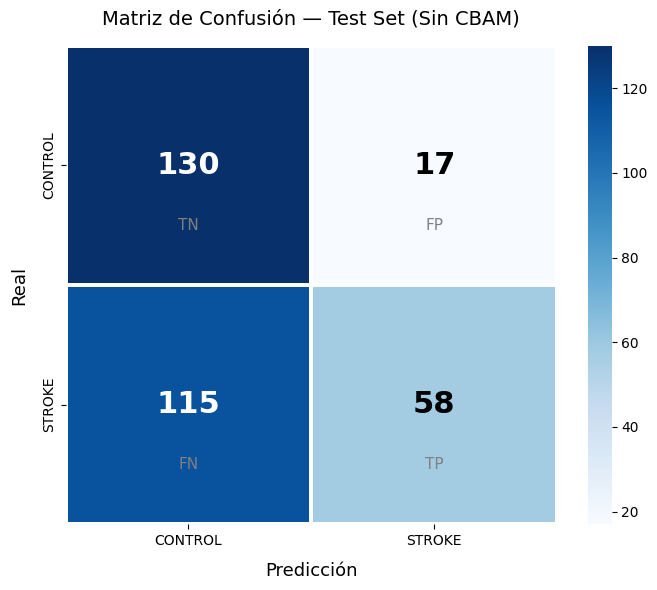

In [234]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set (Sin CBAM)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# **Efficent-B0**

In [7]:
class EfficientNetB0(nn.Module):
    def __init__(self):
        super().__init__()

        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Adaptar primera capa de 3 a 2 canales
        old_weight = base.features[0][0].weight.data
        new_weight = old_weight[:, :2, :, :].clone() * (3 / 2)

        new_conv = nn.Conv2d(2, 32, kernel_size=3, stride=2, padding=1, bias=False)
        new_conv.weight = nn.Parameter(new_weight)
        base.features[0][0] = new_conv

        self.features  = base.features
        self.avgpool   = nn.AdaptiveAvgPool2d(1)
        self.fc        = nn.Linear(1280, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x).flatten(1)
        x = self.fc(x)
        return x

modelo = EfficientNetB0().to(DEVICE)

with torch.no_grad():
    salida = modelo(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo.parameters())
print(f"Entrada      : {imagenes.shape}")
print(f"Salida       : {salida.shape}")
print(f"Parámetros   : {total_params:,}")

Entrada      : torch.Size([16, 2, 112, 112])
Salida       : torch.Size([16, 1])
Parámetros   : 4,008,541


<h2><b> Entrenamiento

In [20]:
# Desbalance corregido
n_control  = sum(1 for f in archivos_train if "CONTROL" in f.stem)
n_stroke   = sum(1 for f in archivos_train if "STROKE"  in f.stem)
pos_weight = torch.tensor([n_stroke / n_control], dtype=torch.float32).to(DEVICE)
print(f"CONTROL: {n_control} | STROKE: {n_stroke} | pos_weight: {pos_weight.item():.3f}")

criterio  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(modelo.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

PACIENCIA         = 7
mejor_val_auc     = 0.0
epocas_sin_mejora = 0
mejor_modelo      = None

MODELO_DIR  = Path("modelos")
MODELO_DIR.mkdir(exist_ok=True)
MODELO_PATH = MODELO_DIR / "efficientnet_mejor_center_4.pth"

historial = {"train_loss": [], "val_loss": [],
             "train_acc":  [], "val_acc":  [], "val_auc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    # Train
    modelo.train()
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()
        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    # Val
    modelo.eval()
    val_loss, val_correctos = 0.0, 0
    all_probs, all_labels   = [], []

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            salida   = modelo(imagenes)
            loss     = criterio(salida, labels)
            val_loss     += loss.item()
            probs         = torch.sigmoid(salida)
            preds         = (probs >= 0.5).float()
            val_correctos += (preds == labels).sum().item()
            all_probs.extend(probs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)
    val_auc     = roc_auc_score(all_labels, all_probs)
    scheduler.step()
    tiempo      = time.time() - inicio

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)
    historial["val_auc"].append(val_auc)

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} auc: {val_auc:.4f} | "
          f"{tiempo:.1f}s")

    if val_auc > mejor_val_auc:
        mejor_val_auc     = val_auc
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo.state_dict())
        torch.save(mejor_modelo, MODELO_PATH)
        print(f"  ✔ Mejor modelo guardado (val_auc: {mejor_val_auc:.4f})")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_auc: {mejor_val_auc:.4f}")
print(f"Modelo guardado en: {MODELO_PATH}")

CONTROL: 475 | STROKE: 549 | pos_weight: 1.156
Época 01/30 | Train loss: 0.5152 acc: 0.7588 | Val loss: 0.3271 acc: 0.8711 auc: 0.9374 | 16.2s
  ✔ Mejor modelo guardado (val_auc: 0.9374)
Época 02/30 | Train loss: 0.3256 acc: 0.8877 | Val loss: 0.4120 acc: 0.8359 auc: 0.9468 | 4.3s
  ✔ Mejor modelo guardado (val_auc: 0.9468)
Época 03/30 | Train loss: 0.2942 acc: 0.9004 | Val loss: 0.2444 acc: 0.9023 auc: 0.9639 | 4.2s
  ✔ Mejor modelo guardado (val_auc: 0.9639)
Época 04/30 | Train loss: 0.2583 acc: 0.9219 | Val loss: 0.3148 acc: 0.8906 auc: 0.9537 | 4.1s
  Sin mejora 1/7
Época 05/30 | Train loss: 0.2109 acc: 0.9268 | Val loss: 0.2813 acc: 0.9023 auc: 0.9510 | 4.2s
  Sin mejora 2/7
Época 06/30 | Train loss: 0.1943 acc: 0.9326 | Val loss: 0.2401 acc: 0.9180 auc: 0.9687 | 4.1s
  ✔ Mejor modelo guardado (val_auc: 0.9687)
Época 07/30 | Train loss: 0.2027 acc: 0.9346 | Val loss: 0.1871 acc: 0.9492 auc: 0.9746 | 4.1s
  ✔ Mejor modelo guardado (val_auc: 0.9746)
Época 08/30 | Train loss: 0.1327 

<h2> <b> Evaluación

In [8]:
MODELO_DIR  = Path("modelos")
MODELO_PATH = MODELO_DIR / "efficientnet_mejor_center_4.pth"
print(MODELO_PATH)
print(MODELO_PATH.exists())

modelos\efficientnet_mejor_center_4.pth
True


In [15]:
# Cargar el mejor modelo
archivos_test = sorted(TEST_DIR.glob("*.npy"))

print(f"Total test : {len(archivos_test)}")
print(f"STROKE     : {sum(1 for f in archivos_test if 'STROKE'  in f.stem)}")
print(f"CONTROL    : {sum(1 for f in archivos_test if 'CONTROL' in f.stem)}")

# Dataset y loader
dataset_test = StrokeDataset(archivos_test)
loader_test  = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

# Cargar el mejor modelo
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo(imagenes)
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)

print("RESULTADOS — VALIDACIÓN")

print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")

Total test : 320
STROKE     : 173
CONTROL    : 147
RESULTADOS — VALIDACIÓN
  AUC-ROC       : 0.5019
  Accuracy      : 0.5188
  F1-Score      : 0.1979
  Sensibilidad  : 0.1098  (detecta STROKE)
  Especificidad : 1.0000  (detecta CONTROL)
  Precisión     : 1.0000


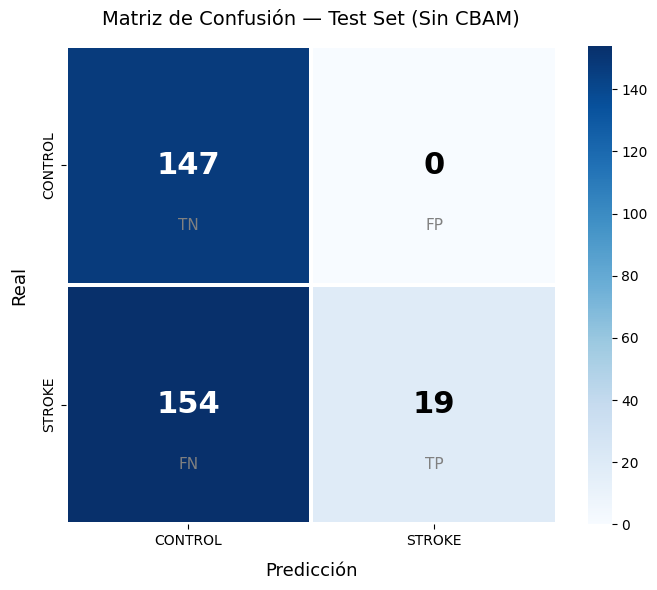

In [16]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set (Sin CBAM)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()